We shall train on a few thousand surnames from 18 languages of origin, and predic which language a name is from based on the spelling

In [1]:
# 依赖
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence
import time
import matplotlib.pyplot as plt
import numpy as np
import gzip
import csv
import math

In [3]:
# data prepare
HIDDEN_SIZE = 100
BATCH_SIZE = 256
N_LAYER = 2
N_EPOCHS = 100
N_CHARS = 128
USE_GPU = True
  
class NameDataset(Dataset):
    def __init__(self, is_train_set=True):
        """
        这个文件是第一列为名字，第二列为国家
        :param is_train_set: 用于判断文件类型
        """
        filename = 'names_train.csv.gz' if is_train_set else 'names_test.csv.gz'
        with gzip.open(filename, 'rt') as f:
            reader = csv.reader(f)
            rows = list(reader)

        # 获取名字和国家的列表，此时每个名字和国家是一一对应的，索引相同
        self.names = [row[0] for row in rows]
        self.len = len(self.names)    # 名字的数量
        self.countries = [row[1] for row in rows]

        # 先将国家列表去重、排序，然后将国家和对应索引组成字典
        self.country_list = list(sorted(set(self.countries)))    # 国家列表
        self.country_dict = self.getCountryDict()
        self.country_num = len(self.country_list)
 
    def __getitem__(self, index):
        return self.names[index], self.country_dict[self.countries[index]]
 
    def __len__(self):
        return self.len
 
    def getCountryDict(self):
        """
        创建一个空字典 -- country_dict
        for循环，取出当前循环次数，和当前循环的名字
        存放字典，对应索引，
        :return:将列表转换为字典。（键，键值）
        """
        country_dict = dict()
        for idx, country_name in enumerate(self.country_list, 0):    # 从0开始, 枚举国家
            country_dict[country_name] = idx
 
        return country_dict
 
    def idx2country(self, index):
        return self.country_list[index]
 
    def getCountriesNum(self):
        return self.country_num

trainset = NameDataset(is_train_set=True)
trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
testset = NameDataset(is_train_set=False)
testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False)
N_COUNTRY = trainset.getCountriesNum()
  
def create_tensor(tensor):
    if USE_GPU:
        device = torch.device("cuda:0")
        tensor = tensor.to(device)
 
    return tensor

Traning for 100 epochs...
 0s] Epoch 1[2560 / 13374]loss = 0.008964271936565637
 0s] Epoch 1[5120 / 13374]loss = 0.007719373889267444
 1s] Epoch 1[7680 / 13374]loss = 0.006987550916771094
 1s] Epoch 1[10240 / 13374]loss = 0.006483526807278395
 1s] Epoch 1[12800 / 13374]loss = 0.00613057354465127
evaluating trained model ...
Test set: Accuracy 4483 / 6700 66.91 %
 1s] Epoch 2[2560 / 13374]loss = 0.004260412650182843
 2s] Epoch 2[5120 / 13374]loss = 0.00406816495815292
 2s] Epoch 2[7680 / 13374]loss = 0.004004772030748427
 2s] Epoch 2[10240 / 13374]loss = 0.0039318999974057075
 2s] Epoch 2[12800 / 13374]loss = 0.0038531347410753368
evaluating trained model ...
Test set: Accuracy 4949 / 6700 73.87 %
 3s] Epoch 3[2560 / 13374]loss = 0.00317091653123498
 3s] Epoch 3[5120 / 13374]loss = 0.0031365733593702316
 3s] Epoch 3[7680 / 13374]loss = 0.003099708918792506
 3s] Epoch 3[10240 / 13374]loss = 0.0031100383959710596
 3s] Epoch 3[12800 / 13374]loss = 0.0030815182393416764
evaluating trained m

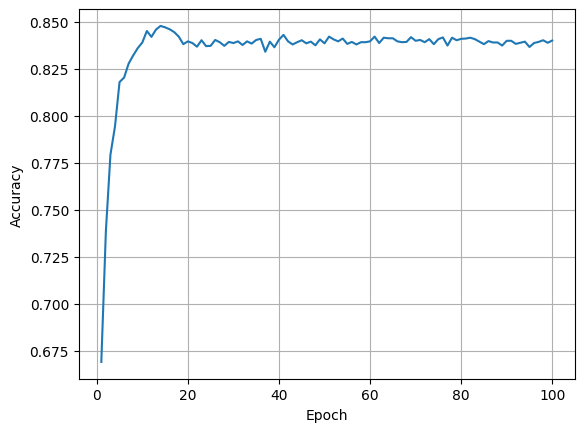

In [5]:
# RNN classifier
class RNNClassifier(torch.nn.Module):
    def __init__(self, input_size, hidden_size, output_size, n_layers=1, bidirectional=True):
        super(RNNClassifier, self).__init__()
        self.hidden_size = hidden_size
        self.n_layers = n_layers
        self.n_directions = 2 if bidirectional else 1
        self.embedding = torch.nn.Embedding(input_size, hidden_size)
        self.gru = torch.nn.GRU(hidden_size, hidden_size, n_layers,
                                bidirectional=bidirectional)
        self.fc = torch.nn.Linear(hidden_size * self.n_directions, output_size)
 
    def _init_hidden(self, batch_size):
        hidden = torch.zeros(self.n_layers * self.n_directions,
                             batch_size, self.hidden_size)
 
        return create_tensor(hidden)
 
    def forward(self, input, seq_lengths):
        #input shape: B x S --> S x B  转置
        input = input.t()
        batch_size = input.size(1)
 
        hidden = self._init_hidden(batch_size)
        embedding = self.embedding(input)
 
        # pack_padded_sequence 要求 lengths 是 CPU 上的 int64 张量
        gru_input = pack_padded_sequence(embedding, seq_lengths.cpu())
 
        output, hidden = self.gru(gru_input, hidden)
        if self.n_directions == 2:
            hidden_cat = torch.cat([hidden[-1], hidden[-2]], dim=1)
        else:
            hidden_cat = hidden[-1]
        fc_output = self.fc(hidden_cat)
 
        return fc_output
 
 
def name2list(name):

    arr = [ord(c) for c in name]
 
    return arr, len(arr)
 
 
def make_tensors(names, countries):
    sequences_and_lengths = [name2list(name) for name in names]
    name_sequences = [s1[0] for s1 in sequences_and_lengths]
    seq_lengths = torch.LongTensor([s1[1] for s1 in sequences_and_lengths])
 
    #make rensor of name, BatchSize x SeqLen
    seq_tensor = torch.zeros(len(name_sequences), seq_lengths.max()).long()
    for idx, (seq, seq_len) in enumerate(zip(name_sequences, seq_lengths), 0):
        seq_tensor[idx, :seq_len] = torch.LongTensor(seq)
 
    #sort by length to use pack_padded_sequence
    seq_lengths, perm_idx = seq_lengths.sort(dim=0, descending=True)
    seq_tensor = seq_tensor[perm_idx]
    countries = countries[perm_idx]
 
    # seq_lengths 给 pack_padded_sequence 用，必须留在 CPU
    return create_tensor(seq_tensor), \
        seq_lengths, \
        create_tensor(countries)
 
 
def time_since(since):
    """
    时间计时模块
    """
    s = time.time() - since
    m = math.floor(s / 60)
    s -= m * 60
 
    return '%dm %ds' % (m, s)
 
 
def trainModel():
    total_loss = 0
    for i, (names, countries) in enumerate(trainloader, 1):
        inputs, seq_lengths, target = make_tensors(names, countries)
        output = classifier(inputs, seq_lengths)
        loss = criterion(output, target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
 
        total_loss += loss.item()
        if i % 10 == 0:
            print(f'[{time_since(start)}] Epoch {epoch}', end='')
            print(f'[{i * len(inputs)} / {len(trainset)}]', end='')
            print(f'loss = {total_loss / (i * len(inputs))}')
 
    return total_loss
 
 
def testModel():
    correct = 0
    total = len(testset)
    print("evaluating trained model ...")
    with torch.no_grad():
        for i, (names, countries) in enumerate(testloader, 1):
            inputs, seq_lengths, target = make_tensors(names, countries)
            output = classifier(inputs, seq_lengths)
            pred = output.max(dim=1, keepdim=True)[1]
            correct += pred.eq(target.view_as(pred)).sum().item()
 
        percent = '%.2f' % (100 * correct / total)
        print(f'Test set: Accuracy {correct} / {total} {percent} %')
 
    return correct / total
 
 
if __name__ == '__main__':
    classifier = RNNClassifier(N_CHARS, HIDDEN_SIZE, N_COUNTRY, N_LAYER)
    if USE_GPU:
        device = torch.device("cuda:0")
        classifier.to(device)
 
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(classifier.parameters(), lr=0.001)
 
    start = time.time()
    print("Traning for %d epochs..." % N_EPOCHS)
    acc_list = []
    for epoch in range(1, N_EPOCHS + 1):
        #Train cycle
        trainModel()
        acc = testModel()
        acc_list.append(acc)
 
epoch = np.arange(1, len(acc_list) + 1, 1)
acc_list = np.array(acc_list)
plt.plot(epoch, acc_list)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid()
plt.show()